In [250]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0,'../build/src/')
import libimp


In [251]:
np.random.seed(42)
days = pd.date_range(start="2015-01-01", periods=20*365, freq="D")

base_temperature = 15 
seasonal_effect = 10 * np.sin(2 * np.pi * days.dayofyear / 365)  
noise = np.random.normal(0, 0.1, len(days))  
base_temperature_small_trend = 0 #15 + 0.0009 * np.arange(len(days))  
temperature_series_small_trend = base_temperature_small_trend + seasonal_effect + noise

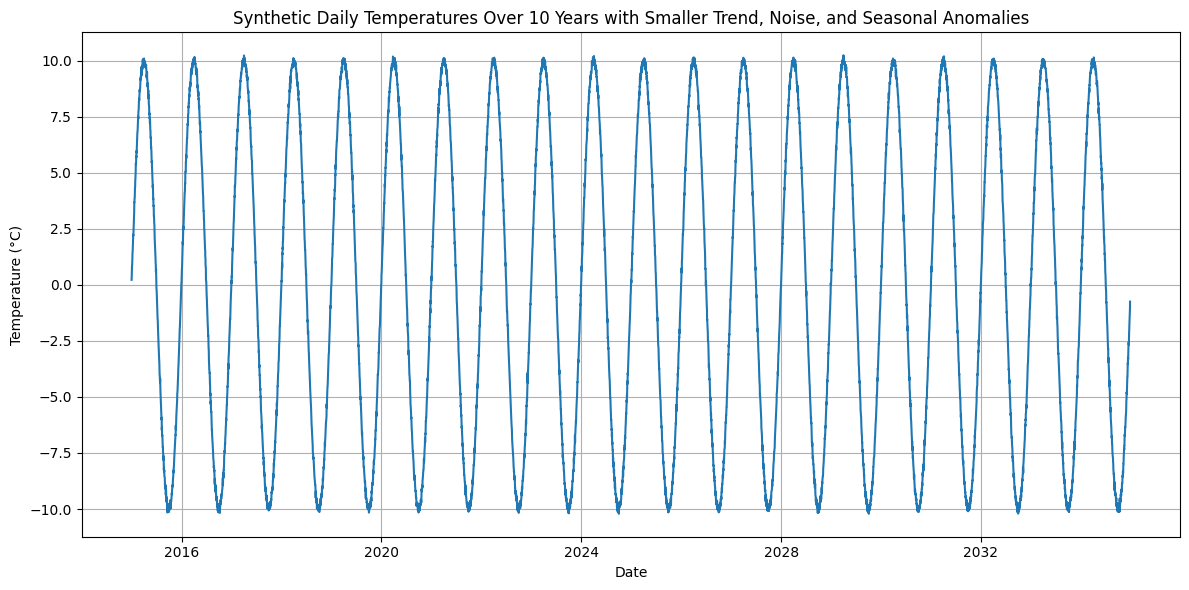

In [252]:
temperature_df_small_trend = pd.DataFrame({
    'Date': days,
    'Temperature': temperature_series_small_trend
})
temperature_df_small_trend.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(temperature_df_small_trend.index, temperature_df_small_trend['Temperature'], color='tab:blue')
plt.title("Synthetic Daily Temperatures Over 10 Years with Smaller Trend, Noise, and Seasonal Anomalies")
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [253]:
num_anomalies = 1  
anomaly_dates = np.array([
    np.datetime64("2022-11-15"),
    np.datetime64("2020-07-15"),
    np.datetime64("2017-04-15"),
    np.datetime64("2030-05-15"),
]) 


for date in anomaly_dates:
    anomaly_range = pd.date_range(start=date - pd.Timedelta(days=3), end=date + pd.Timedelta(days=3))
    temperature_df_small_trend.loc[anomaly_range, 'Temperature'] += np.array([0.6,0.7,0.8,0.9,1,0.5,0.2])+2

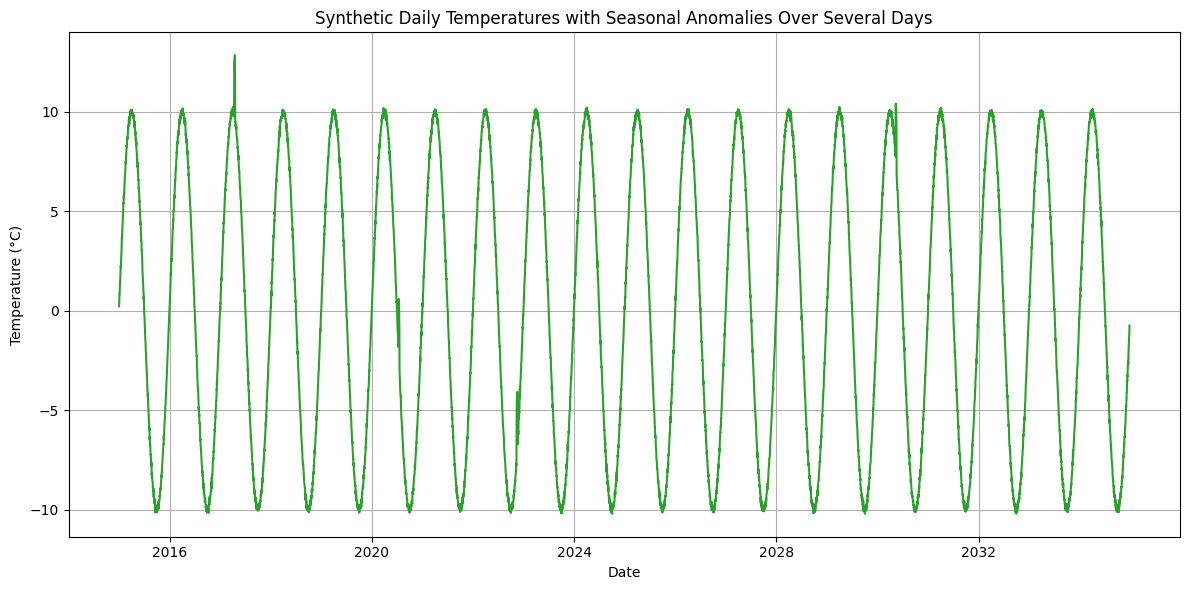

In [254]:
plt.figure(figsize=(12, 6))
plt.plot(temperature_df_small_trend.index, temperature_df_small_trend['Temperature'], color='tab:green')
plt.title("Synthetic Daily Temperatures with Seasonal Anomalies Over Several Days")
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

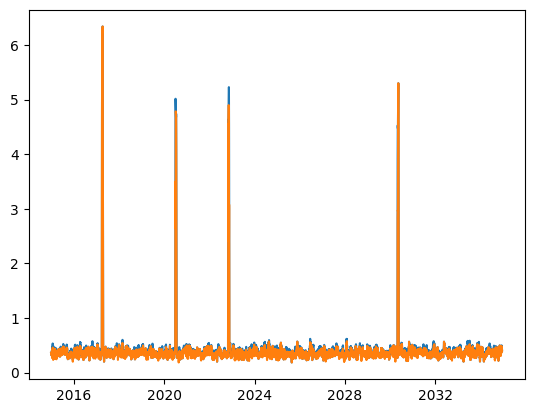

In [255]:
ts = temperature_df_small_trend.Temperature.values
period_starts = np.array([i*365 for i in range(10)]) 
window_size = 14
interval_length = 60
exclude = 7
mp, mp_index = libimp.mp_double(ts, window_size, exclude, 500, 500)
imp, imp_index = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)
plt.plot(temperature_df_small_trend.index[:len(mp)], imp)
plt.plot(temperature_df_small_trend.index[:len(mp)], mp) 
